# Series로 1차원 배열 다루기

In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np

### 1. Series 
- 판다스의 1차원 배열 구조를 가짐

In [3]:
s1 = pd.Series([1, 2, 3])
s1

0    1
1    2
2    3
dtype: int64

In [7]:
array1 = np.array([1, 2, 3, 4, 5])
s1 = pd.Series(array1, index=['a', 'b', 'c', 'd', 'e'])
s1

a    1
b    2
c    3
d    4
e    5
dtype: int64

In [8]:
dict1 = {"number" : [1, 2, 3]}
s1 = pd.Series(dict1)
s1

number    [1, 2, 3]
dtype: object

In [11]:
dict2 = {
    'apple': '🍎',
    'orange': '🍅',
    'lemon': '🍋'
        }
s1 = pd.Series(dict2)
print(s1)
print(s1.index)

apple     🍎
orange    🍅
lemon     🍋
dtype: object
Index(['apple', 'orange', 'lemon'], dtype='object')


### 2. Series 기본 정보 확인

In [12]:
# 데이터 생성
s = pd.Series([1, 2, 3])
s

0    1
1    2
2    3
dtype: int64

In [16]:
# 사이즈 확인 - Series.size
print(len(s), s.size)

3 3


In [17]:
# 사이즈 형태 확인
s.shape

(3,)

In [18]:
# 사이즈의 데이터 타입 확인
s.dtype

dtype('int64')

In [21]:
# 사이즈의 인덱스 확인
print(f"인덱스 범위: {s.index}")
print(f"인덱스 값: {s.index.values}")

인덱스 범위: RangeIndex(start=0, stop=3, step=1)
인덱스 값: [0 1 2]


### 3. iloc & loc
- 인덱스 검색 방식
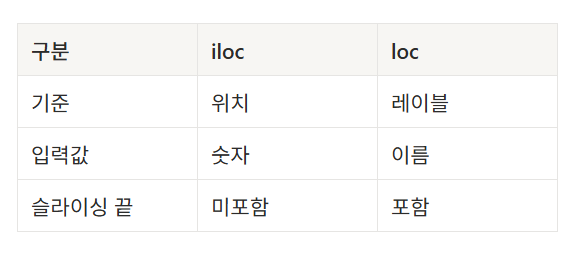

In [23]:
s1 = pd.Series([1, 2, 3])
s1

0    1
1    2
2    3
dtype: int64

In [34]:
# iloc 인덱싱
# 0번지 인덱스 검색
s1.iloc[0]        # np.int64(1)
print(s1.iloc[0]) # 1

1


In [41]:
# 0, 1 인덱스 슬라이싱
print(s1.iloc[0:1])  # 1제외
print(s1.iloc[0:2])  # 2제외 0, 1 출력

0    1
dtype: int64
0    1
1    2
dtype: int64


In [42]:
# loc 인덱싱
s2 = pd.Series([1, 2, 3], index=['a','b','c'])
s2

a    1
b    2
c    3
dtype: int64

In [48]:
print(s2.loc['a'])
print(s2.loc['c'])
# print(s2.loc['a', 'c']) 에러 발생
# print(s2.loc[0])  에러 발생

1
3


In [49]:
# loc 슬라이싱 - 마지막 인덱스 포함
print(s2['a':'b']) # 'b' 인덱스 포함

a    1
b    2
dtype: int64


### 4. 조건 슬라이싱

In [52]:
narray = np.arange(100, 1000, 100)
s3 = pd.Series(narray)
s3

0    100
1    200
2    300
3    400
4    500
5    600
6    700
7    800
8    900
dtype: int64

In [54]:
# s3 데이터가 500보다 큰 데이터만 출력
s4 = s3[s3 > 500]
s4

5    600
6    700
7    800
8    900
dtype: int64

In [56]:
# &(and), |(or) 
# 300이상, 500미만
s5 = s3[(s3 >= 300) & (s3 < 500)]
s6 = s3[(s3 >= 300) | (s3 < 500)]
print(s5)
print(s6)

2    300
3    400
dtype: int64
0    100
1    200
2    300
3    400
4    500
5    600
6    700
7    800
8    900
dtype: int64


In [58]:
# where(조건절)
s7 = s3.where(s3 > 500)
print(s7)

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
5    600.0
6    700.0
7    800.0
8    900.0
dtype: float64


### 5. 통계 함수
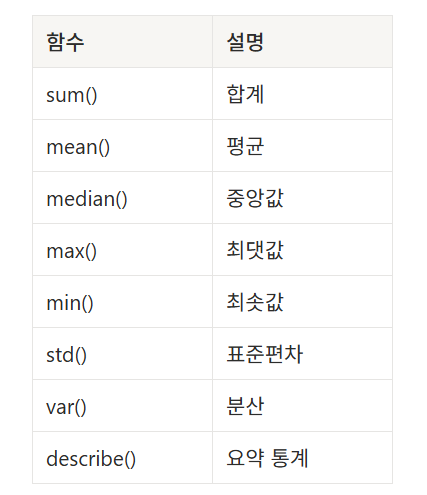

In [65]:
numbers = pd.Series(np.arange(1, 10))
numbers

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64

In [66]:
# 합계, 평균, 중앙값
print(f"sum : {numbers.sum()}")
print(f"mean : {numbers.mean()}")
print(f"median : {numbers.median()}")
print(f"min : {numbers.min()}")
print(f"max : {numbers.max()}")
print(f"describe : {numbers.describe()}")

sum : 45
mean : 5.0
median : 5.0
min : 1
max : 9
describe : count    9.000000
mean     5.000000
std      2.738613
min      1.000000
25%      3.000000
50%      5.000000
75%      7.000000
max      9.000000
dtype: float64


### 6. 산술연산

In [ ]:
numbers2 = numbers *2  # deep copy(깊은복사 - 독립적인 객체로 생성)
print(numbers)
print(numbers2)

In [72]:
# 섭씨 -> 화씨로 변환
numbers = pd.Series([10.5, 23.6, 27, 25, 19]) # 섭씨 온도
fnumbers = numbers * 9/5 +32 # 화씨 구하는 공식 - 객체 * 9/5 +32
print(f"섭씨 : {numbers}")
print("="* 50)
print(f"화씨 : {fnumbers}")

섭씨 : 0    10.5
1    23.6
2    27.0
3    25.0
4    19.0
dtype: float64
화씨 : 0    50.90
1    74.48
2    80.60
3    77.00
4    66.20
dtype: float64


### 7. 데이터 수정, 추가, 삭제

In [73]:
scores = pd.Series([70, 90, 80, 100],
                    index=['국어', '영어', '수학', '과학'])
scores

국어     70
영어     90
수학     80
과학    100
dtype: int64

In [75]:
# 국어 점수를 90점으로 수정
scores['국어'] = 90
scores

국어     90
영어     90
수학     80
과학    100
dtype: int64

In [77]:
# 수학 점수 100으로 수정
scores.loc['수학']
scores['수학'] = 100
scores

국어     90
영어     90
수학    100
과학    100
dtype: int64

In [80]:
# 사회(80) 인덱스 추가 
scores['사회'] = 80  # '사회' 없으면 추가, 있으면 수정
scores

국어     90
영어     90
수학    100
과학    100
사회     80
dtype: int64

In [85]:
# 객체.drop(인덱스)
# '사회' 인덱스 삭제
scores2 = scores.drop('사회')  # deep copy
print(scores)
print(scores2)

국어     90
영어     90
수학    100
과학    100
사회     80
dtype: int64
국어     90
영어     90
수학    100
과학    100
dtype: int64


### 8. copy() 

In [ ]:
numbers = pd.Series(np.arange(1, 10))
numbers

In [89]:
# numbers 객체를 copy() 함수를 통해 복사, deep copy - 독립객체로 생성, 원본 그대로 유지
numbers_copy = numbers.copy()
numbers_copy[4] = 500

In [ ]:
print(numbers)
print(numbers_copy)

In [92]:
# numbers 객체의 주소를 다른 변수에 저장, 주소 공유 형태, shallow copy - 원본 객체를 함께 공유함
numbers_copy2 = numbers
numbers_copy2[4] = 500

In [93]:
print(numbers)
print(numbers_copy2)

0      1
1      2
2      3
3      4
4    500
5      6
6      7
7      8
8      9
dtype: int64
0      1
1      2
2      3
3      4
4    500
5      6
6      7
7      8
8      9
dtype: int64
